<a href="https://colab.research.google.com/github/mtnleo/Uni_AI_1/blob/main/Guia_6_Leonardi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Ejercicios Prácticos**

**Ejercicio 1: Experimentar con el parámetro de difusividad (m)**

Generar un conjunto de 300 datos con 2 caracteristicas y 3 conjuntos usando make_blobs, pruebe modificando el parametro cluster_std= con valores 1.5 a 3

1.  Ejecutar FCM con m=1.2, m=2 (el valor por defecto) y m=3.
2.  Para cada valor, observa la matriz de pertenencia U para los puntos en las zonas de transición.
3.  ¿Cómo cambia la entropía (incertidumbre) de las pertenencias a medida que m aumenta?
4.  ¿Qué efecto tiene m en el FPC?




In [2]:
!pip install scikit-fuzzy # Correr para el skfuzzy de abajo, sino da error

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 35.4 MB/s eta 0:00:00


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import skfuzzy as fuzz # Correr primero la install del pip, porque sino no corre!

# Generar un conjunto de 300 datos con 2 características y 3 conjuntos
# Usamos cluster_std=2.0 para forzar el solapamiento y crear zonas de transición
X, y_true = make_blobs(n_samples=300, n_features=2, centers=3, cluster_std=2.0, random_state=42)

X_fcm = X.T

# 1. Ejecutar FCM con m=1.2, m=2 y m=3.
m_values = [1.2, 2.0, 3.0]
resultados = {}

for m in m_values:
    # La función devuelve múltiples valores; pero interesan los centroides (cntr),
    # la matriz de pertenencia (u) y el coeficiente FPC (fpc)
    cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
        X_fcm, c=3, m=m, error=0.005, maxiter=1000, init=None
    )
    resultados[m] = {'u': u, 'fpc': fpc, 'cntr': cntr}

# 2. Para cada valor, observa la matriz de pertenencia U
# para los puntos en las zonas de transición.

centro_global = np.mean(X, axis=0)
distancias_al_centro = np.linalg.norm(X - centro_global, axis=1)
idx_transicion = np.argmin(distancias_al_centro)

print(f"Punto en zona de transición (Índice {idx_transicion}): {X[idx_transicion].round(2)}\n")

for m in m_values:
    u_punto = resultados[m]['u'][:, idx_transicion]
    print(f"--- m = {m} ---")
    print(f"Pertenencias (U): {u_punto.round(4)}")
    print(f"FPC del modelo: {resultados[m]['fpc']:.4f}\n")

Punto en zona de transición (Índice 188): [-1.84 -0.08]

--- m = 1.2 ---
Pertenencias (U): [0.1066 0.8358 0.0575]
FPC del modelo: 0.9959

--- m = 2.0 ---
Pertenencias (U): [0.2899 0.2626 0.4475]
FPC del modelo: 0.8640

--- m = 3.0 ---
Pertenencias (U): [0.3934 0.309  0.2976]
FPC del modelo: 0.6078



###3. ¿Cómo cambia la entropía (incertidumbre) de las pertenencias a medida que m aumenta?
La entropía (incertidumbre) aumenta. Matemáticamente, el parámetro m (difusividad) controla cuánto se relaja la condición de agrupamiento. Al aumentar m, el algoritmo penaliza las asignaciones categóricas ("duras"). Por lo tanto, las probabilidades en la matriz U para los puntos en zonas de transición tienden a aplanarse y distribuirse casi equitativamente entre los clusters (acercándose a 1/c, que en este caso sería aprox. 0.33 para cada grupo).

### 4. ¿Qué efecto tiene m en el FPC?

A medida que m aumenta, el FPC (Fuzzy Partition Coefficient) disminuye. El FPC es una métrica que evalúa qué tan "nítida" es la separación de los clusters (1 es una partición dura perfecta, y 1/c es máxima difusión). Al forzar distribuciones de probabilidad más planas con un m mayor, la sumatoria de los cuadrados de las pertenencias cae, reduciendo el puntaje FPC general del modelo.

---
**Ejercicio 2: Identificar puntos ambiguos**

1.  Encuentra los 10 puntos con mayor entropía (mayor incertidumbre).
2.  Visualiza estos puntos en un gráfico, marcándolos de forma especial (por ejemplo, con un contorno negro).
3.  ¿Dónde se ubican estos puntos en relación con los centroides?




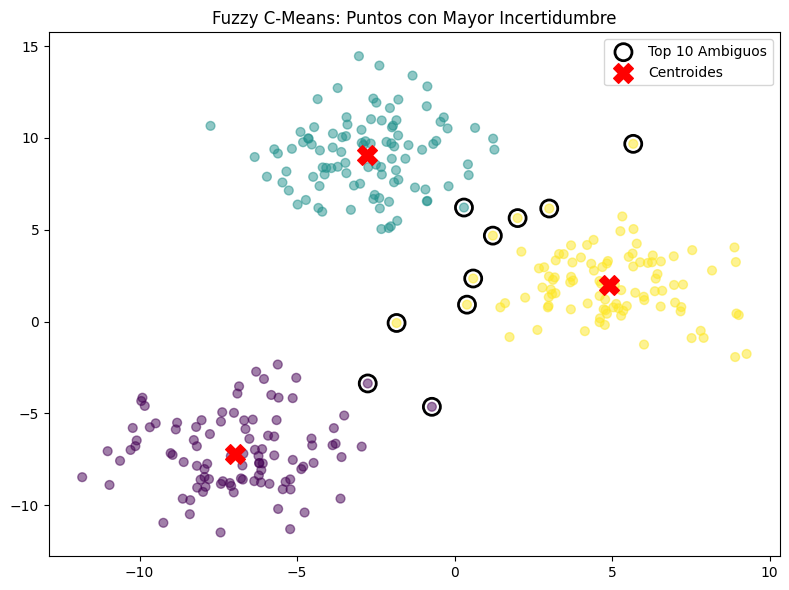

In [4]:
# 1. Encuentra los 10 puntos con mayor entropía (mayor incertidumbre)
# Utilizamos la matriz de pertenencia del modelo estándar (m=2.0)
u_m2 = resultados[2.0]['u']
centroides = resultados[2.0]['cntr']

# Calculamos la entropía de Shannon: H = -sum(p * log(p))
entropia = -np.sum(u_m2 * np.log(u_m2 + 1e-9), axis=0)

idx_ambiguos = np.argsort(entropia)[-10:]

# 2. Visualiza estos puntos en un gráfico
# Obtenemos el cluster "ganador" para pintar el fondo
etiquetas_duras = np.argmax(u_m2, axis=0)

plt.figure(figsize=(8, 6))

# Graficamos todos los puntos
plt.scatter(X[:, 0], X[:, 1], c=etiquetas_duras, cmap='viridis', s=40, alpha=0.5)

# Remarcamos los 10 puntos más ambiguos con un contorno negro más grande (ayuda de la IA para mejorar visualizacion)
plt.scatter(X[idx_ambiguos, 0], X[idx_ambiguos, 1], facecolors='none',
            edgecolors='black', linewidths=2, s=150, label='Top 10 Ambiguos')

# Grafico
plt.scatter(centroides[:, 0], centroides[:, 1], c='red', marker='X', s=200, label='Centroides')

plt.title('Fuzzy C-Means: Puntos con Mayor Incertidumbre')
plt.legend()
plt.tight_layout()
plt.show()

# 3. ¿Dónde se ubican estos puntos en relación con los centroides?
# Se ubican exactamente en las zonas de transición o fronteras de decisión,
# en las areas donde se solapan los clusters.
# Al tener distancias muy similares entre 2 o mas centroides,
# el algoritmo no tiene evidencia matematica para inclinarse a uno de ellos
# por lo que distribuye sus grados de pertenencia y aumenta la entropia

---
**Ejercicio 3: FCM con diferentes números de clusters**

1.  Aplica FCM con c=2, c=3 y c=4.
2.  Calcula el FPC para cada caso.
3.  Basándote en el FPC, ¿cuál sería el número óptimo de clusters? ¿Coincide con la realidad?





Para c = 2, el coeficiente FPC es: 0.8409
Para c = 3, el coeficiente FPC es: 0.8640
Para c = 4, el coeficiente FPC es: 0.7633


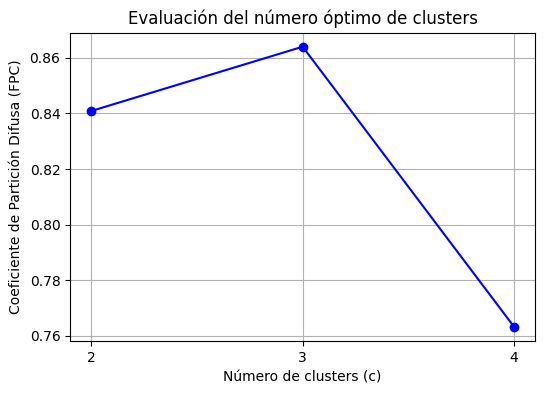

In [5]:
# 1 y 2. Aplica FCM con c=2, c=3 y c=4, y calcula el FPC para cada caso.
valores_c = [2, 3, 4]
fpcs = []

for c in valores_c:
    # Entrenamos el modelo iterando sobre la cantidad de clusters
    cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
        X_fcm, c=c, m=2.0, error=0.005, maxiter=1000, init=None
    )
    fpcs.append(fpc)
    print(f"Para c = {c}, el coeficiente FPC es: {fpc:.4f}")

# Graficamos los resultados para una mejor interpretación
plt.figure(figsize=(6, 4))
plt.plot(valores_c, fpcs, marker='o', linestyle='-', color='b')
plt.title('Evaluación del número óptimo de clusters')
plt.xlabel('Número de clusters (c)')
plt.ylabel('Coeficiente de Partición Difusa (FPC)')
plt.xticks(valores_c)
plt.grid(True)
plt.show()

### 3. Basándote en el FPC, ¿cuál sería el número óptimo de clusters?

El número óptimo de clusters es aquel que maximiza el valor del FPC. Al observar los resultados impresos y el gráfico, se nota que el pico más alto (el valor más cercano a 1) se da cuando c = 3.

### 4. ¿Coincide con la realidad?

Sí, coincide perfectamente. En el Ejercicio 1 generé el dataset sintético utilizando make_blobs con el parámetro centers=3, por lo que matemáticamente existen 3 grupos reales en los datos. El FPC logró identificar esta estructura correctamente penalizando a c=2 (subagrupamiento) y c=4 (sobreagrupamiento).

---
**Ejercicio 4: FCM en datos reales**

1.  Carga el dataset de iris desde `sklearn.datasets.load_iris()`.
2.  Aplica FCM para agrupar las flores en 3 clusters.
3.  Compara la matriz de pertenencia con las especies reales. ¿Hay flores con alta incertidumbre? ¿Corresponden a especies que son difíciles de distinguir (ej. versicolor y virginica)?
4.  Visualiza los resultados usando las dos primeras características, coloreando por la especie real y marcando la incertidumbre.



Análisis de puntos con alta incertidumbre ---
Especies de las 15 flores más ambiguas: [np.str_('virginica'), np.str_('virginica'), np.str_('virginica'), np.str_('versicolor'), np.str_('virginica'), np.str_('virginica'), np.str_('virginica'), np.str_('versicolor'), np.str_('versicolor'), np.str_('virginica'), np.str_('versicolor'), np.str_('versicolor'), np.str_('versicolor'), np.str_('versicolor'), np.str_('versicolor')]



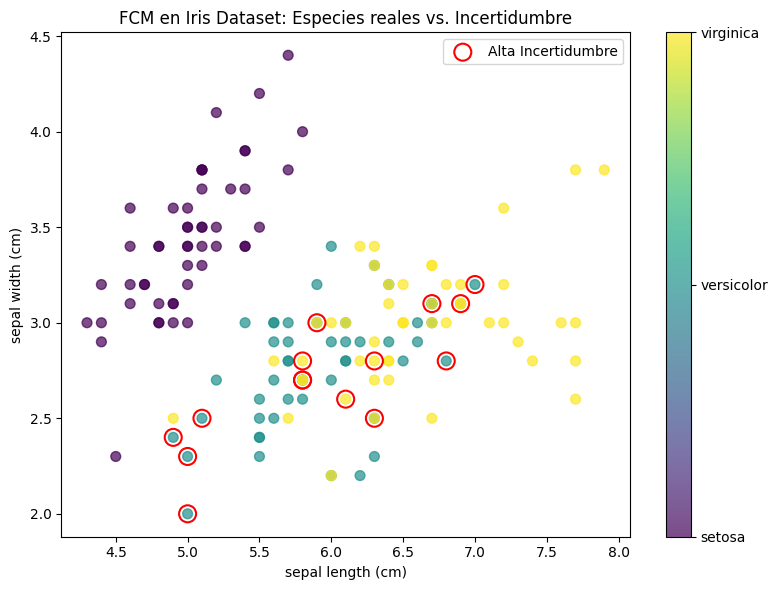

In [6]:
from sklearn.datasets import load_iris
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz

# 1. Carga el dataset de iris
iris = load_iris()
X = iris.data
y_real = iris.target
X_fcm = X.T

# 2. Aplica FCM para agrupar las flores en 3 clusters
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    X_fcm, c=3, m=2.0, error=0.005, maxiter=1000, init=None
)

# 3. Análisis de incertidumbre
# Calculo la entropía para identificar las flores más ambiguas
entropia = -np.sum(u * np.log(u + 1e-9), axis=0)

# Selecciono los 15 puntos con mayor incertidumbre
idx_ambiguos = np.argsort(entropia)[-15:]

print("Análisis de puntos con alta incertidumbre ---")
especies_ambiguas = y_real[idx_ambiguos]
nombres_especies = [iris.target_names[e] for e in especies_ambiguas]
print(f"Especies de las 15 flores más ambiguas: {nombres_especies}\n")

# 4. Visualiza los resultados usando las dos primeras características
plt.figure(figsize=(8, 6))

# Grafico todos los puntos coloreados por su especie real
scatter = plt.scatter(X[:, 0], X[:, 1], c=y_real, cmap='viridis', s=50, alpha=0.7)
plt.colorbar(scatter, ticks=[0, 1, 2], format=plt.FuncFormatter(lambda val, loc: iris.target_names[int(val)]))

# Marco los puntos de alta incertidumbre detectados por FCM
plt.scatter(X[idx_ambiguos, 0], X[idx_ambiguos, 1], facecolors='none',
            edgecolors='red', linewidths=1.5, s=150, label='Alta Incertidumbre')

plt.title('FCM en Iris Dataset: Especies reales vs. Incertidumbre')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.legend()
plt.tight_layout()
plt.show()

### 3. ¿Hay flores con alta incertidumbre? ¿Corresponden a especies que son difíciles de distinguir?

Sí, hay flores con una alta incertidumbre en sus grados de pertenencia. Como se comprueba al imprimir los nombres de esos puntos ambiguos, corresponden casi en su totalidad a las clases versicolor y virginica.

Por su lado, la especie setosa es linealmente separable y el algoritmo le asigna pertenencias "duras" (cercanas a 1). Sin embargo, versicolor y virginica presentan un solapamiento natural en sus medidas físicas (el largo y ancho del pétalo/sépalo son muy similares), lo que se traduce matemáticamente en una zona de transición donde FCM no puede definir con certeza el agrupamiento y reparte las probabilidades.

---

**Ejercicio 5: Importancia de la normalización**

1.  Añade una característica de escala diferente a los datos (ej. `X[:, 0] * 100`).
2.  Aplica FCM sin normalizar y con normalización (StandardScaler).
3.  Compara los resultados. ¿Qué observas sobre la influencia de las escalas en FCM?


In [10]:
!pip install fuzzy-c-means # para FCM

--- Centroides SIN Normalizar ---
[[4.94730399e+02 3.20729418e+00 1.82244301e+00 3.96898318e-01]
 [6.95935169e+02 3.07031105e+00 5.54667631e+00 1.93956251e+00]
 [5.94965171e+02 2.90900005e+00 4.37461741e+00 1.45237701e+00]]

--- Centroides CON Normalización ---
[[ 1.06924711  0.03742416  0.97017333  1.02978812]
 [-1.00478337  0.84648483 -1.28465359 -1.23864587]
 [-0.03836591 -0.81872278  0.32296956  0.23214992]]


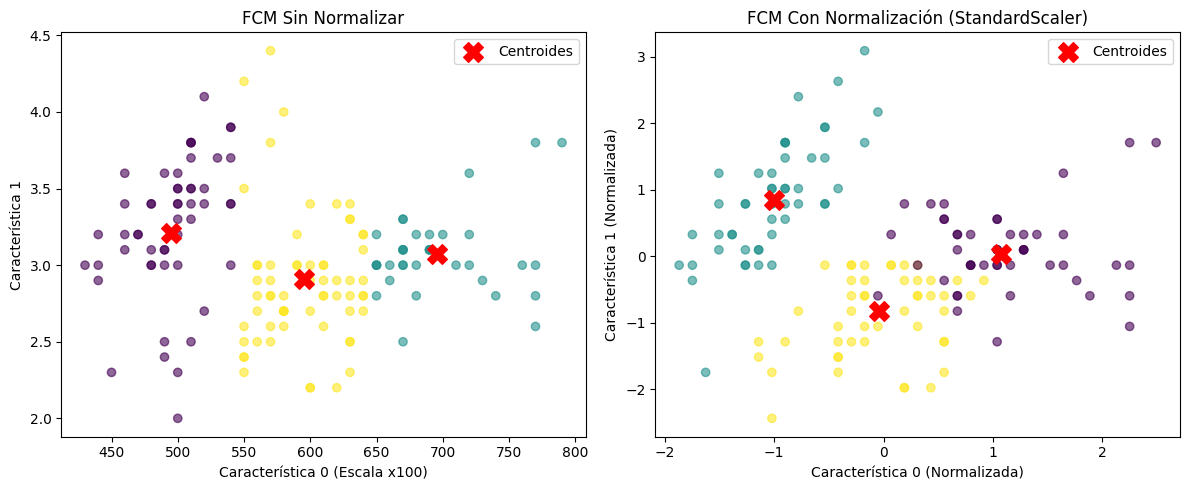

In [15]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from fcmeans import FCM

# 1. Añadir una escala diferente a la primera característica
X_unscaled = X.copy()
X_unscaled[:, 0] = X_unscaled[:, 0] * 100

# 2. Aplicar normalización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unscaled)

# 3. Entrenar FCM sin normalizar
fcm_unscaled = FCM(n_clusters=3)
fcm_unscaled.fit(X_unscaled)
labels_unscaled = fcm_unscaled.predict(X_unscaled)
centers_unscaled = fcm_unscaled.centers

# 4. Entrenar FCM con normalización
fcm_scaled = FCM(n_clusters=3)
fcm_scaled.fit(X_scaled)
labels_scaled = fcm_scaled.predict(X_scaled)
centers_scaled = fcm_scaled.centers

## VISUALIZACION
print("--- Centroides SIN Normalizar ---")
print(centers_unscaled)
print("\n--- Centroides CON Normalización ---")
print(centers_scaled)

# Graficar los resultados
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1: Sin normalizar
axes[0].scatter(X_unscaled[:, 0], X_unscaled[:, 1], c=labels_unscaled, cmap='viridis', alpha=0.6)
axes[0].scatter(centers_unscaled[:, 0], centers_unscaled[:, 1], marker='X', s=200, c='red', label='Centroides')
axes[0].set_title('FCM Sin Normalizar')
axes[0].set_xlabel('Característica 0 (Escala x100)')
axes[0].set_ylabel('Característica 1')
axes[0].legend()

# Gráfico 2: Con normalización
axes[1].scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_scaled, cmap='viridis', alpha=0.6)
axes[1].scatter(centers_scaled[:, 0], centers_scaled[:, 1], marker='X', s=200, c='red', label='Centroides')
axes[1].set_title('FCM Con Normalización (StandardScaler)')
axes[1].set_xlabel('Característica 0 (Normalizada)')
axes[1].set_ylabel('Característica 1 (Normalizada)')
axes[1].legend()

plt.tight_layout()
plt.show()

### 3. ¿Qué observas sobre la influencia de las escalas?

Sin normalizar: Los clusters se alinean y dividen basándose casi exclusivamente en la característica 0 (la que multiplicaste por 100), ignorando los patrones del resto de las variables.

Con normalización: Los clusters vuelven a reflejar la estructura multidimensional original de los datos.